# Exploratory Data Analysis (EDA) and Data Cleaning
**ChurnGuard AI Project**

This notebook performs a comprehensive EDA on the Telco Customer Churn dataset. We will:
1. Handle missing values and correct data types.
2. Analyze the distribution of features.
3. Explore the relationship between features and the target variable (`Churn`).
4. Save the cleaned dataset for the modeling pipeline.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')


## 1. Data Loading
Let's load the raw dataset and inspect the first few rows.


In [12]:
data_path = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(data_path)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Cleaning
Let's check the data types and look for missing values.


In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Notice that `TotalCharges` is currently an `object` (string) type, but it should be numeric. Let's convert it. We will force errors to `NaN` so we can see how many missing values exist.


In [14]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for missing values
missing = df.isnull().sum()
print("Missing values in each column:")
print(missing[missing > 0])


Missing values in each column:
TotalCharges    11
dtype: int64


We have 11 missing values in `TotalCharges`. Since this is a very small number out of 7043, we can safely drop these rows. 
We will also drop the `customerID` column as it is not a useful feature for prediction.


In [15]:
# Drop missing values
df.dropna(inplace=True)

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

print(f"Dataset shape after cleaning: {df.shape}")


Dataset shape after cleaning: (7032, 20)


## 3. Exploratory Data Analysis (EDA)
### Target Variable Distribution
Let's see how many customers churned versus how many stayed.


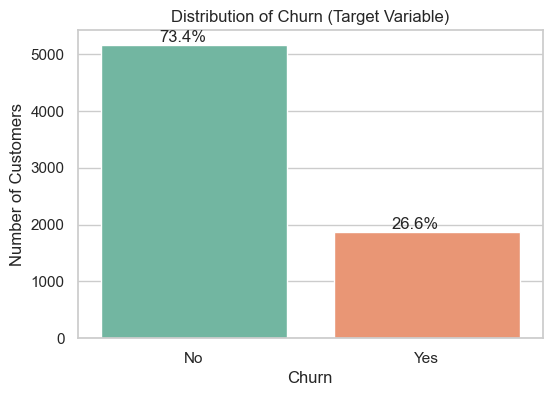

In [16]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribution of Churn (Target Variable)')
plt.ylabel('Number of Customers')

# Calculate percentages
total = len(df['Churn'])
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), ha='center')
plt.show()


The dataset is imbalanced. About 26.6% of the customers churned. We will need to keep this in mind during modeling (which is why our cost-sensitive thresholding is so important!).

### Numerical Features
Let's look at the distributions of `tenure`, `MonthlyCharges`, and `TotalCharges`.


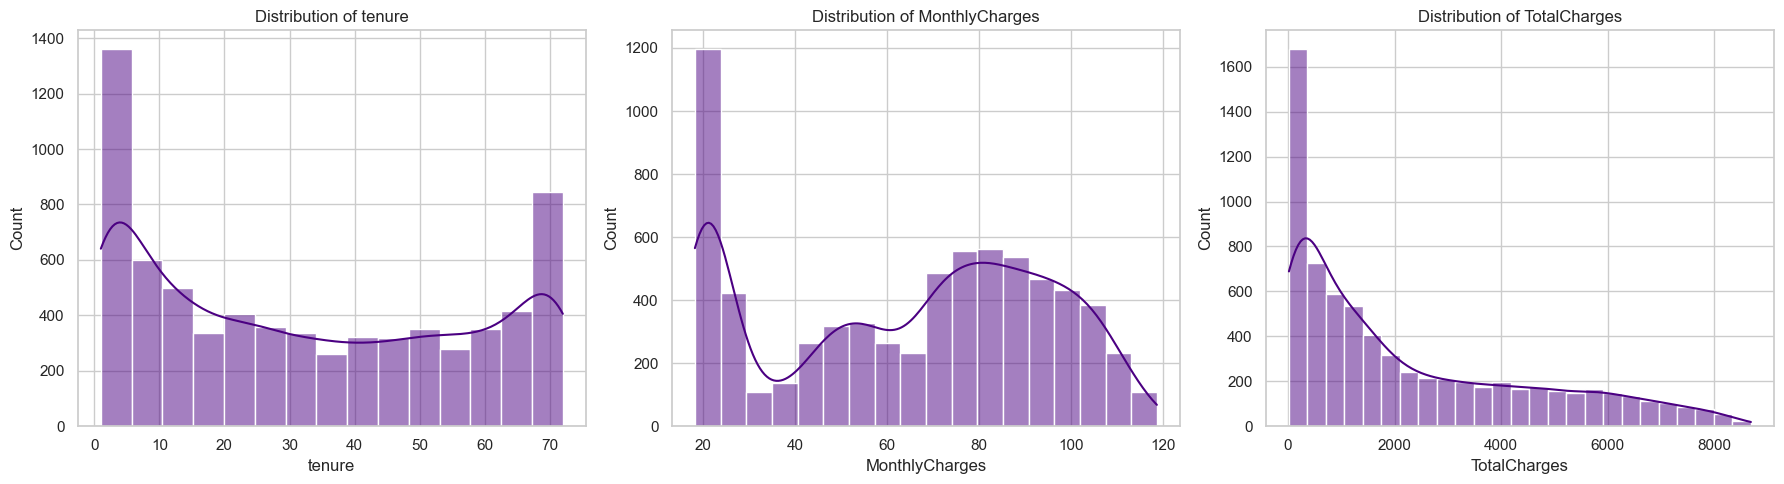

In [17]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(num_features):
    sns.histplot(df[feature], kde=True, ax=axes[i], color='indigo')
    axes[i].set_title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()


Let's see how these numerical features relate to Churn.


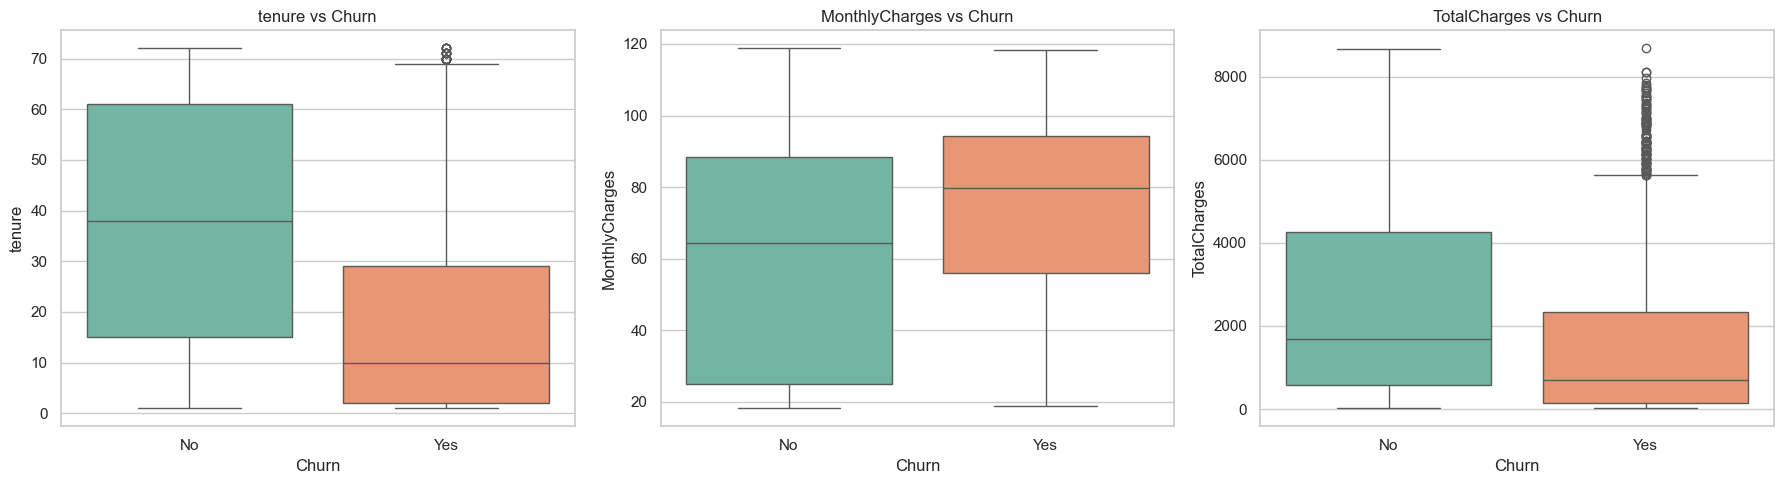

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(num_features):
    sns.boxplot(x='Churn', y=feature, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feature} vs Churn')
plt.tight_layout()
plt.show()


**Insights:**
- **Tenure:** Customers who churn tend to have much shorter tenure. They leave early.
- **Monthly Charges:** Customers who churn tend to have higher monthly charges.
- **Total Charges:** This is correlated with tenure.

### Categorical Features
Let's examine some key categorical features, like `Contract`, `InternetService`, and `PaymentMethod`.


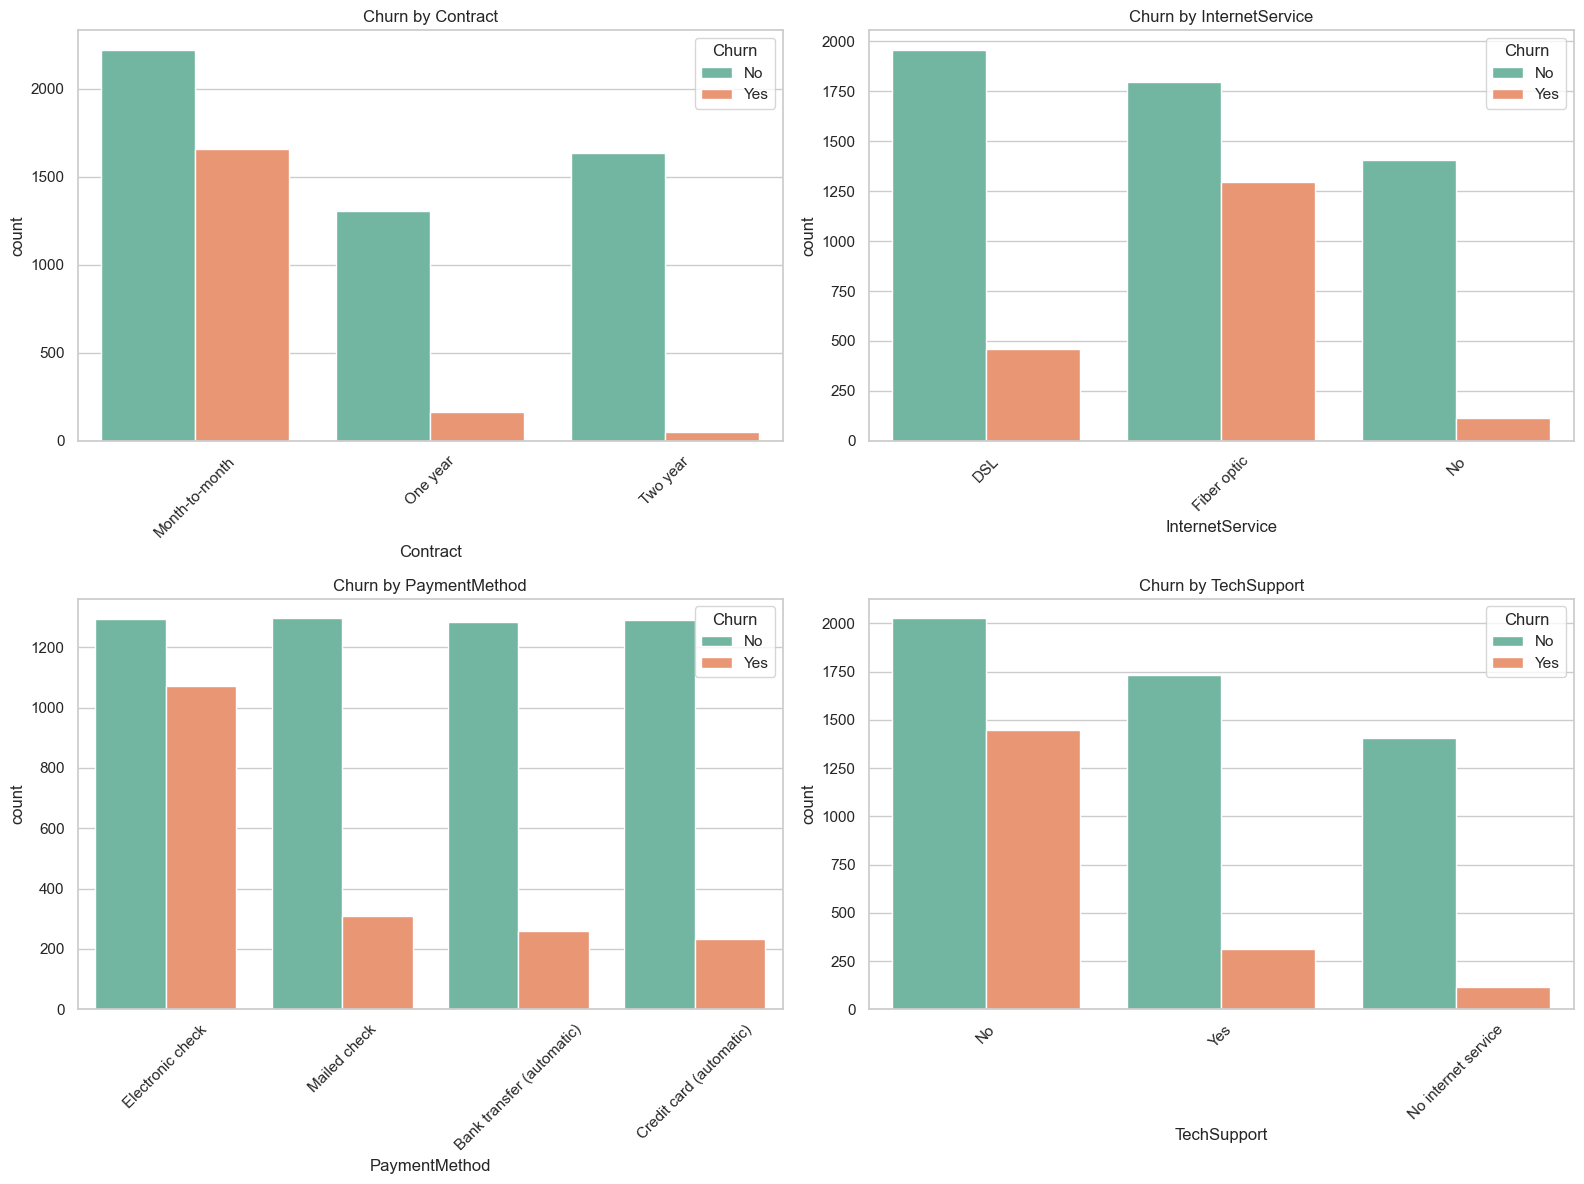

In [19]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(cat_features):
    sns.countplot(x=feature, hue='Churn', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Churn by {feature}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Insights:**
- **Contract:** Month-to-month contracts have a drastically higher churn rate compared to 1 or 2-year contracts.
- **Internet Service:** Fiber optic customers are churning at a very high rate compared to DSL. This might indicate a price or quality issue with the Fiber service.
- **Payment Method:** Electronic check is associated with much higher churn.
- **Tech Support:** Customers *without* tech support churn much more often.

## 4. Saving the Cleaned Dataset
We've cleaned the data (handled missing values, fixed types, removed IDs). We will now save it so the model training pipeline can pick it up.


In [20]:
import os
os.makedirs('../data/processed', exist_ok=True)
processed_path = '../data/processed/cleaned_data.csv'
df.to_csv(processed_path, index=False)
print(f"Cleaned data saved to {processed_path}")


Cleaned data saved to ../data/processed/cleaned_data.csv
